In [265]:
from bs4 import BeautifulSoup
# import pandas as pd
from datetime import datetime, timedelta
from itertools import combinations
import json
import requests
import math
from typing import Optional, List, Dict
import os

from pydantic import BaseModel
from typing import Mapping
import numpy as np
import polars as pl
import hvplot.polars
import pandas as pd
import altair as alt
import math

from shared.utils import formalize_data_with_str
from shared.random_rules import RandomRules

In [266]:
rr = RandomRules(
  TOTAL_NUMBERS = 50,
  CHOOSE = 6,
  MAX_PRIMES = 3,
  N_VALUES=["1", "2", "3"],
  # Rangos de valores de las bolillas
  MIN_B_VALUES = [1, 2, 3, 4, 5, 6],
  MAX_B_VALUES = [45, 46, 47, 48, 49, 50]
)

In [267]:
url = 'https://resultados.latinka.com.pe/i.do?m=historico&t=0&s=41'
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

tables = soup.select('table')
rows = tables[1].find_all('tr')

In [268]:
lst = []
post_str_b1 = None
post_str_b2 = None
post_str_b3 = None
post_str_b4 = None
post_str_b5 = None
post_str_blast = None
for row in rows:
  cols = [data.text.strip() for data in row.find_all('td')]
  
  id, bolillas_int, str_combo = formalize_data_with_str(bolillas_str=cols[2])
  cols.append(id)
  cols.append(bolillas_int)
  cols.extend([b for b in bolillas_int])
  cols.extend(str_combo)
  cols.append(post_str_b1)
  cols.append(post_str_b2)
  cols.append(post_str_b3)
  cols.append(post_str_b4)
  cols.append(post_str_b5)
  cols.append(post_str_blast)

  is_rare, reason = rr.is_rare_combination(bolillas_int, id)
  cols.append(is_rare)
  cols.append(reason)

  cols.append(rr.jumps_map(bolillas_int))
  cols.append(rr.unijump(bolillas_int))
  cols.append(rr.prime_counter(bolillas_int))
  cols.append(rr.evens_counter(bolillas_int))
  cols.append(rr.odds_counter(bolillas_int))

  jumps = rr.jumps(bolillas_int)
  cols.append(jumps[0])
  cols.append(jumps[1])
  cols.append(jumps[2])
  cols.append(jumps[3])
  cols.append(jumps[4])
  sum_jumps = sum(jumps)
  cols.append(sum(jumps))
  cols.append(sum([1 for j in jumps if j > 9]))
  cols.append(len(list(set(jumps))))
  cols.append(int(any([b == sum_jumps for b in bolillas_int])))
  
  lst.append(cols)

  post_str_b1 = str_combo[0]
  post_str_b2 = str_combo[1]
  post_str_b3 = str_combo[2]
  post_str_b4 = str_combo[3]
  post_str_b5 = str_combo[4]
  post_str_blast = str_combo[-1]

with open('./gn_tnk_v3.json', 'w') as file: 
  json.dump(lst, file)

dfRows = pl.DataFrame(
  lst,
  schema=[
    'fecha', 'sorteo', 'bolillas', 'yapa', 'adicionales', 'sorteo_extra',
    'id', 'combo', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6',
    'str_b1', 'str_b2', 'str_b3', 'str_b4', 'str_b5', 'str_b6',
    'post_str_b1', 'post_str_b2', 'post_str_b3', 'post_str_b4', 'post_str_b5', 'post_str_blast',
    'is_rare_combination', 'reason',
    "jumps_map", "unijump",
    "primes_count", "evens_count", "odds_count",
    "j1", "j2", "j3", "j4", "j5", "jsum", "joor", "jdiff", "hjsum"
  ],
  schema_overrides={
    'combo': pl.Array(pl.UInt8, 6),
    'b1': pl.UInt8,
    'b2': pl.UInt8,
    'b3': pl.UInt8,
    'b4': pl.UInt8,
    'b5': pl.UInt8,
    'b6': pl.UInt8,
    'reason': pl.UInt8,

    'primes_count': pl.String,
    'evens_count': pl.String,
    'odds_count': pl.String,
    "j1": pl.String,
    "j2": pl.String,
    "j3": pl.String,
    "j4": pl.String,
    "j5": pl.String,
    "jsum": pl.String,
    "joor": pl.String,
    "jdiff": pl.String,
    "jsum": pl.String,
    "hjsum": pl.String
  },
  orient='row'
)

TOTAL_LINES = len(dfRows)
print(f'{TOTAL_LINES=}')
display(dfRows.head(10))
dfRows.write_parquet('dfrows_tnk.parquet')

TOTAL_LINES=2546


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""14/01/2026""","""1264""","""33 18 42 07 20 12""","""22""","""28 21""","""Promoción Sí o Sí""","""071218203342""","[7, 12, … 42]",7,12,18,20,33,42,"""07""","""12""","""18""","""20""","""33""","""42""",null,null,null,null,null,null,false,0,"""05_06_02_13_09""",-50,"""1""","""4""","""2""","""5""","""6""","""2""","""13""","""9""","""35""","""1""","""5""","""0"""
"""11/01/2026""","""1263""","""38 28 17 40 35 05""","""11""","""49 19""","""Promoción Sí o Sí""","""051728353840""","[5, 17, … 40]",5,17,28,35,38,40,"""05""","""17""","""28""","""35""","""38""","""40""","""07""","""12""","""18""","""20""","""33""","""42""",false,0,"""12_11_07_03_02""",0,"""2""","""3""","""3""","""12""","""11""","""7""","""3""","""2""","""35""","""2""","""5""","""1"""
"""07/01/2026""","""1262""","""05 34 26 02 09 47""","""40""","""35 27 49""","""Promoción Sí o Sí""","""020509263447""","[2, 5, … 47]",2,5,9,26,34,47,"""02""","""05""","""09""","""26""","""34""","""47""","""05""","""17""","""28""","""35""","""38""","""40""",true,16,"""03_04_17_08_13""",70,"""3""","""3""","""3""","""3""","""4""","""17""","""8""","""13""","""45""","""2""","""5""","""0"""
"""04/01/2026""","""1261""","""23 49 26 48 39 21""","""01""","""30""","""Promoción Sí o Sí""","""212326394849""","[21, 23, … 49]",21,23,26,39,48,49,"""21""","""23""","""26""","""39""","""48""","""49""","""02""","""05""","""09""","""26""","""34""","""47""",false,0,"""02_03_13_09_01""",33,"""1""","""2""","""4""","""2""","""3""","""13""","""9""","""1""","""28""","""1""","""5""","""0"""
"""31/12/2025""","""1260""","""38 35 44 47 37 28""","""45""","""03 49""","""Promoción Sí o Sí""","""283537384447""","[28, 35, … 47]",28,35,37,38,44,47,"""28""","""35""","""37""","""38""","""44""","""47""","""21""","""23""","""26""","""39""","""48""","""49""",true,16,"""07_02_01_06_03""",-16,"""2""","""3""","""3""","""7""","""2""","""1""","""6""","""3""","""19""","""0""","""5""","""0"""
"""28/12/2025""","""1259""","""06 13 31 22 11 16""","""19""","""15 10""","""Promoción Sí o Sí""","""061113162231""","[6, 11, … 31]",6,11,13,16,22,31,"""06""","""11""","""13""","""16""","""22""","""31""","""28""","""35""","""37""","""38""","""44""","""47""",false,0,"""05_02_03_06_09""",0,"""3""","""3""","""3""","""5""","""2""","""3""","""6""","""9""","""25""","""0""","""5""","""0"""
"""24/12/2025""","""1258""","""16 13 31 08 24 33""","""01""","""45 11 22""","""Promoción Sí o Sí""","""081316243133""","[8, 13, … 33]",8,13,16,24,31,33,"""08""","""13""","""16""","""24""","""31""","""33""","""06""","""11""","""13""","""16""","""22""","""31""",false,0,"""05_03_08_07_02""",15,"""2""","""3""","""3""","""5""","""3""","""8""","""7""","""2""","""25""","""0""","""5""","""0"""
"""21/12/2025""","""1257""","""25 27 23 36 14 10""","""38""","""03""","""Promoción Sí o Sí""","""101423252736""","[10, 14, … 36]",10,14,23,25,27,36,"""10""","""14""","""23""","""25""","""27""","""36""","""08""","""13""","""16""","""24""","""31""","""33""",true,8,"""04_09_02_02_09""",-19,"""1""","""3""","""3""","""4""","""9""","""2""","""2""","""9""","""26""","""0""","""3""","""0"""
"""17/12/2025""","""1256""","""14 25 10 13 12 39""","""49""","""37 09 29""","""Promoción Sí o Sí""","""101213142539""","[10, 12, … 39]",10,12,13,14,25,39,"""10""","""12""","""13""","""14""","""25""","""39""","""10""","""14""","""23""","""25""","""27""","""36""",true,8,"""02_01_01_11_14""",-26,"""1""","""3""","""3""","""2""","""1""","""1""","""11""","""14""","""29""","""2""","""4""","""0"""


In [269]:
dfRows.filter(
  pl.col("b1") > 10
)

fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""04/01/2026""","""1261""","""23 49 26 48 39 21""","""01""","""30""","""Promoción Sí o Sí""","""212326394849""","[21, 23, … 49]",21,23,26,39,48,49,"""21""","""23""","""26""","""39""","""48""","""49""","""02""","""05""","""09""","""26""","""34""","""47""",false,0,"""02_03_13_09_01""",33,"""1""","""2""","""4""","""2""","""3""","""13""","""9""","""1""","""28""","""1""","""5""","""0"""
"""31/12/2025""","""1260""","""38 35 44 47 37 28""","""45""","""03 49""","""Promoción Sí o Sí""","""283537384447""","[28, 35, … 47]",28,35,37,38,44,47,"""28""","""35""","""37""","""38""","""44""","""47""","""21""","""23""","""26""","""39""","""48""","""49""",true,16,"""07_02_01_06_03""",-16,"""2""","""3""","""3""","""7""","""2""","""1""","""6""","""3""","""19""","""0""","""5""","""0"""
"""14/12/2025""","""1255""","""19 37 50 27 35 14""","""39""","""08""","""Promoción Sí o Sí""","""141927353750""","[14, 19, … 50]",14,19,27,35,37,50,"""14""","""19""","""27""","""35""","""37""","""50""","""10""","""12""","""13""","""14""","""25""","""39""",true,8,"""05_08_08_02_13""",26,"""2""","""2""","""4""","""5""","""8""","""8""","""2""","""13""","""36""","""1""","""4""","""0"""
"""07/12/2025""","""1253""","""45 46 32 28 11 43""","""35""","""10 02""","""Promoción Sí o Sí""","""112832434546""","[11, 28, … 46]",11,28,32,43,45,46,"""11""","""28""","""32""","""43""","""45""","""46""","""07""","""21""","""36""","""38""","""47""","""48""",false,0,"""17_04_11_02_01""",60,"""2""","""3""","""3""","""17""","""4""","""11""","""2""","""1""","""35""","""2""","""5""","""0"""
"""03/12/2025""","""1252""","""29 25 28 43 12 33""","""27""","""31 26 34 37""","""Promoción Sí o Sí""","""122528293343""","[12, 25, … 43]",12,25,28,29,33,43,"""12""","""25""","""28""","""29""","""33""","""43""","""11""","""28""","""32""","""43""","""45""","""46""",false,0,"""13_03_01_04_10""",1,"""2""","""2""","""4""","""13""","""3""","""1""","""4""","""10""","""31""","""2""","""5""","""0"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""10/09/1995""","""0048""","""11 19 20 21 24 36""","""""","""""","""""","""111920212436""","[11, 19, … 36]",11,19,20,21,24,36,"""11""","""19""","""20""","""21""","""24""","""36""","""10""","""13""","""17""","""21""","""23""","""32""",true,8,"""08_01_01_03_12""",10,"""2""","""3""","""3""","""8""","""1""","""1""","""3""","""12""","""25""","""1""","""4""","""0"""
"""23/07/1995""","""0041""","""14 18 21 25 29 30""","""""","""""","""""","""141821252930""","[14, 18, … 30]",14,18,21,25,29,30,"""14""","""18""","""21""","""25""","""29""","""30""","""03""","""04""","""06""","""10""","""16""","""29""",true,8,"""04_03_04_04_01""",1,"""1""","""3""","""3""","""4""","""3""","""4""","""4""","""1""","""16""","""0""","""3""","""0"""
"""09/04/1995""","""0026""","""16 18 24 25 29 31""","""""","""""","""""","""161824252931""","[16, 18, … 31]",16,18,24,25,29,31,"""16""","""18""","""24""","""25""","""29""","""31""","""01""","""03""","""19""","""27""","""30""","""35""",false,0,"""02_06_01_04_02""",-30,"""2""","""3""","""3""","""2""","""6""","""1""","""4""","""2""","""15""","""0""","""4""","""0"""


In [270]:

def count_column (df: pl.DataFrame, col_name: str, k: int = None) -> None:
  df_viz = (df if k == None else df[0:k]) \
    .group_by(
      col_name
    ).agg(pl.count(col_name).alias('count')) \
    .sort("count", descending=True)

  chart = df_viz.hvplot.bar(
    x=col_name,
    y='count'
  )

  chart.opts(default_tools=["pan"])
  display(chart)
  return df_viz[col_name].to_list()

jjsum = count_column(dfRows, 'hjsum', 200)
jdiff_count = count_column(dfRows, 'jdiff', 200)

j1_count = count_column(dfRows, 'j1', 200)
j2_count = count_column(dfRows, 'j2', 200)
j3_count = count_column(dfRows, 'j3', 200)
j4_count = count_column(dfRows, 'j4', 200)
j5_count = count_column(dfRows, 'j5', 200)

joor_count = count_column(dfRows, "joor", 200)
primes_count = count_column(dfRows, 'primes_count', 200)
evens_count = count_column(dfRows, 'evens_count', 200)
odds_count = count_column(dfRows, 'odds_count', 200)

jsums = count_column(dfRows, 'jsum', 200)
# print(jsums[0:22])



:Bars   [hjsum]   (count)

:Bars   [jdiff]   (count)

:Bars   [j1]   (count)

:Bars   [j2]   (count)

:Bars   [j3]   (count)

...

:Bars   [joor]   (count)

:Bars   [primes_count]   (count)

:Bars   [evens_count]   (count)

:Bars   [odds_count]   (count)

:Bars   [jsum]   (count)

In [271]:
dfRows.item(0, 'b2')

12

In [272]:
import holoviews as hv
def plot_post_col (col: str, post_col: str, test_value: str | None = None):
  if test_value == None:
    test_value = dfRows.item(0, col)
    print(f'Setting {test_value=}')

  df_viz = dfRows \
    .filter(
      pl.col(col) == test_value,
      pl.col(post_col).is_not_null()
    ) \
    .group_by(
      post_col
    ).agg(pl.count(post_col).alias('count')) \
    .sort("count", descending=True)
  
  
  df_10_last = dfRows \
    .filter(
      pl.col(col) == test_value,
      pl.col(post_col).is_not_null()
    ) \
    .head(10)
  
  # Agrega una columna que sea el porcentaje de la frecuencia relativa
  total = df_viz['count'].sum()
  df_viz = df_viz.with_columns(
    ( (pl.col('count') / total) * 100 ).alias('percent')
  )

  mean_percent = df_viz['percent'].mean()
  mean_percent_75 = mean_percent * 75 / 50
  mean_percent_25 = mean_percent * 25 / 50

  chart = df_viz.hvplot.bar(
    x=post_col,
    y='percent'
  )

  chart = chart * hv.HLine(mean_percent).opts(color='red')
  chart = chart * hv.HLine(mean_percent_75).opts(color='blue')
  chart = chart * hv.HLine(mean_percent_25).opts(color='blue')
  
  chart.opts(default_tools=["pan"])

  df_jumps_map = dfRows \
    .filter(
      pl.col(col) == test_value,
      pl.col(post_col).is_not_null()
    ) \
    .group_by(
      'jumps_map'
    ).agg(pl.count('jumps_map').alias('count')) \
    .sort("count", descending=True)
  
  df_unijump = dfRows \
    .filter(
      pl.col(col) == test_value,
      pl.col(post_col).is_not_null()
    ) \
    .group_by(
      'unijump'
    ).agg(pl.count('unijump').alias('count')) \
    .sort("count", descending=True)


  print(f'df_viz FOR {col} = {test_value}')
  display(df_viz)

  display(chart)
  

  print(f'df_10_last FOR {col} = {test_value}')
  last_results = list(set(df_10_last[post_col][0:3]))
  print(f'Last 3 results {last_results=}')
  display(df_10_last)
  
  print(f'df_jumps_map FOR {col} = {test_value}')
  display(df_jumps_map)
  # display(df_unijump)

  print(f'df_unijump FOR {col} = {test_value}')
  display(df_unijump)

  lst_post_str_b = df_viz.filter(pl.col('percent') >= mean_percent)[post_col].to_list()
  lst_jumps_map = df_jumps_map['jumps_map'].to_list() # Used to discard
  
  return lst_post_str_b, lst_jumps_map, last_results

In [273]:
possible_b1, exclude_jump_maps_b1, last_post_b1 = plot_post_col(col='str_b1', post_col='post_str_b1')

Setting test_value='07'
df_viz FOR str_b1 = 07


post_str_b1,count,percent
str,u32,f64
"""01""",21,15.555556
"""02""",19,14.074074
"""03""",14,10.37037
"""04""",12,8.888889
"""08""",12,8.888889
…,…,…
"""26""",1,0.740741
"""19""",1,0.740741
"""21""",1,0.740741


:Overlay
   .Bars.I    :Bars   [post_str_b1]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b1 = 07
Last 3 results last_results=['14', '01']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""10/12/2025""","""1254""","""36 21 07 38 47 48""","""03""","""23 01 50""","""Promoción Sí o Sí""","""072136384748""","[7, 21, … 48]",7,21,36,38,47,48,"""07""","""21""","""36""","""38""","""47""","""48""","""14""","""19""","""27""","""35""","""37""","""50""",false,0,"""14_15_02_09_01""",-69,"""2""","""3""","""3""","""14""","""15""","""2""","""9""","""1""","""41""","""2""","""5""","""0"""
"""26/11/2025""","""1250""","""14 11 23 07 39 37""","""33""","""17 21""","""Promoción Sí o Sí""","""071114233739""","[7, 11, … 39]",7,11,14,23,37,39,"""07""","""11""","""14""","""23""","""37""","""39""","""01""","""32""","""34""","""37""","""38""","""50""",true,1,"""04_03_09_14_02""",-8,"""4""","""1""","""5""","""4""","""3""","""9""","""14""","""2""","""32""","""1""","""5""","""0"""
"""07/09/2025""","""1227""","""29 15 07 33 17 23""","""08""","""49""","""Promoción Sí o Sí""","""071517232933""","[7, 15, … 33]",7,15,17,23,29,33,"""07""","""15""","""17""","""23""","""29""","""33""","""01""","""06""","""16""","""33""","""38""","""45""",true,11,"""08_02_06_06_04""",16,"""4""","""0""","""6""","""8""","""2""","""6""","""6""","""4""","""26""","""0""","""4""","""0"""
"""17/08/2025""","""1221""","""34 11 39 07 26 27""","""37""","""25 22""","""Promoción Sí o Sí""","""071126273439""","[7, 11, … 39]",7,11,26,27,34,39,"""07""","""11""","""26""","""27""","""34""","""39""","""06""","""09""","""28""","""29""","""37""","""49""",false,0,"""04_15_01_07_05""",-73,"""2""","""2""","""4""","""4""","""15""","""1""","""7""","""5""","""32""","""1""","""5""","""0"""
"""13/08/2025""","""1220""","""36 07 43 32 20 33""","""17""","""41 42""","""Promoción Sí o Sí""","""072032333643""","[7, 20, … 43]",7,20,32,33,36,43,"""07""","""20""","""32""","""33""","""36""","""43""","""07""","""11""","""26""","""27""","""34""","""39""",true,16,"""13_12_01_03_07""",-34,"""2""","""3""","""3""","""13""","""12""","""1""","""3""","""7""","""36""","""2""","""5""","""1"""
"""02/07/2025""","""1208""","""14 28 32 07 10 29""","""36""","""37 27 16""","""Promoción Sí o Sí""","""071014282932""","[7, 10, … 32]",7,10,14,28,29,32,"""07""","""10""","""14""","""28""","""29""","""32""","""03""","""11""","""14""","""15""","""20""","""29""",false,0,"""03_04_14_01_03""",70,"""2""","""4""","""2""","""3""","""4""","""14""","""1""","""3""","""25""","""1""","""4""","""0"""
"""21/05/2025""","""1196""","""07 36 24 34 45 11""","""01""","""33 47""","""Promoción Sí o Sí""","""071124343645""","[7, 11, … 45]",7,11,24,34,36,45,"""07""","""11""","""24""","""34""","""36""","""45""","""01""","""04""","""08""","""09""","""21""","""31""",false,0,"""04_13_10_02_09""",13,"""2""","""3""","""3""","""4""","""13""","""10""","""2""","""9""","""38""","""2""","""5""","""0"""
"""27/04/2025""","""1189""","""46 33 21 08 07 41""","""39""","""36 09 37""","""Promoción Sí o Sí""","""070821334146""","[7, 8, … 46]",7,8,21,33,41,46,"""07""","""08""","""21""","""33""","""41""","""46""","""02""","""06""","""11""","""16""","""33""","""36""",false,0,"""01_13_12_08_05""",-6,"""2""","""2""","""4""","""1""","""13""","""12""","""8""","""5""","""39""","""2""","""5""","""0"""
"""12/03/2025""","""1176""","""44 34 07 17 16 32""","""11""","""47 40""","""Promoción Sí o Sí""","""071617323444""","[7, 16, … 44]",7,16,17,32,34,44,"""07""","""16""","""17""","""32""","""34""","""44""","""05""","""12""","""15""","""27""","""30""","""49""",false,0,"""09_01_15_02_10""",97,"""2""","""4""","""2""","""9""","""1""","""15""","""2""","""10""","""37""","""2""","""5""","""0"""


df_jumps_map FOR str_b1 = 07


jumps_map,count
str,u32
"""02_21_06_01_02""",1
"""06_02_18_05_03""",1
"""01_04_07_07_16""",1
"""01_16_05_03_01""",1
"""01_02_22_08_02""",1
…,…
"""03_03_02_03_12""",1
"""02_01_04_01_07""",1
"""05_07_11_10_01""",1


df_unijump FOR str_b1 = 07


unijump,count
i64,u32
4,5
11,4
-48,3
0,3
-42,3
…,…
-28,1
31,1
38,1


In [274]:
possible_b2, exclude_jump_maps_b2, last_post_b2 = plot_post_col(col='str_b2', post_col='post_str_b2')

Setting test_value='12'
df_viz FOR str_b2 = 12


post_str_b2,count,percent
str,u32,f64
"""08""",12,8.450704
"""13""",11,7.746479
"""16""",10,7.042254
"""06""",10,7.042254
"""12""",8,5.633803
…,…,…
"""33""",1,0.704225
"""35""",1,0.704225
"""27""",1,0.704225


:Overlay
   .Bars.I    :Bars   [post_str_b2]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b2 = 12
Last 3 results last_results=['13', '14', '15']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""17/12/2025""","""1256""","""14 25 10 13 12 39""","""49""","""37 09 29""","""Promoción Sí o Sí""","""101213142539""","[10, 12, … 39]",10,12,13,14,25,39,"""10""","""12""","""13""","""14""","""25""","""39""","""10""","""14""","""23""","""25""","""27""","""36""",true,8,"""02_01_01_11_14""",-26,"""1""","""3""","""3""","""2""","""1""","""1""","""11""","""14""","""29""","""2""","""4""","""0"""
"""26/10/2025""","""1241""","""46 02 17 32 12 15""","""40""","""48 10 43""","""Promoción Sí o Sí""","""021215173246""","[2, 12, … 46]",2,12,15,17,32,46,"""02""","""12""","""15""","""17""","""32""","""46""","""08""","""13""","""14""","""27""","""33""","""44""",false,0,"""10_03_02_15_14""",-36,"""2""","""4""","""2""","""10""","""3""","""2""","""15""","""14""","""44""","""3""","""5""","""0"""
"""31/08/2025""","""1225""","""30 35 32 12 38 04""","""29""","""02""","""Promoción Sí o Sí""","""041230323538""","[4, 12, … 38]",4,12,30,32,35,38,"""04""","""12""","""30""","""32""","""35""","""38""","""14""","""15""","""18""","""21""","""23""","""48""",true,8,"""08_18_02_03_03""",-61,"""0""","""5""","""1""","""8""","""18""","""2""","""3""","""3""","""34""","""1""","""4""","""0"""
"""24/08/2025""","""1223""","""12 37 16 08 22 17""","""07""","""32 27""","""Promoción Sí o Sí""","""081216172237""","[8, 12, … 37]",8,12,16,17,22,37,"""08""","""12""","""16""","""17""","""22""","""37""","""13""","""19""","""30""","""36""","""40""","""46""",true,8,"""04_04_01_05_15""",-11,"""2""","""4""","""2""","""4""","""4""","""1""","""5""","""15""","""29""","""1""","""4""","""0"""
"""09/04/2025""","""1184""","""35 24 49 01 12 39""","""21""","""13 07 26""","""Promoción Sí o Sí""","""011224353949""","[1, 12, … 49]",1,12,24,35,39,49,"""01""","""12""","""24""","""35""","""39""","""49""","""22""","""36""","""39""","""44""","""46""","""48""",false,0,"""11_12_11_04_10""",23,"""0""","""2""","""4""","""11""","""12""","""11""","""4""","""10""","""48""","""4""","""4""","""0"""
"""16/03/2025""","""1177""","""15 30 49 12 05 27""","""23""","""24""","""Promoción Sí o Sí""","""051215273049""","[5, 12, … 49]",5,12,15,27,30,49,"""05""","""12""","""15""","""27""","""30""","""49""","""04""","""32""","""34""","""37""","""41""","""42""",false,0,"""07_03_12_03_19""",74,"""1""","""2""","""4""","""7""","""3""","""12""","""3""","""19""","""44""","""2""","""4""","""0"""
"""09/02/2025""","""1167""","""34 03 46 35 33 12""","""18""","""44 06 41""","""Promoción Sí o Sí""","""031233343546""","[3, 12, … 46]",3,12,33,34,35,46,"""03""","""12""","""33""","""34""","""35""","""46""","""18""","""23""","""24""","""32""","""33""","""44""",true,8,"""09_21_01_01_11""",-62,"""1""","""3""","""3""","""9""","""21""","""1""","""1""","""11""","""43""","""2""","""4""","""0"""
"""02/02/2025""","""1165""","""20 48 14 12 28 04""","""02""","""40""","""Promoción Sí o Sí""","""041214202848""","[4, 12, … 48]",4,12,14,20,28,48,"""04""","""12""","""14""","""20""","""28""","""48""","""12""","""19""","""24""","""27""","""30""","""33""",true,20,"""08_02_06_08_20""",24,"""0""","""6""","""0""","""8""","""2""","""6""","""8""","""20""","""44""","""1""","""4""","""0"""
"""01/12/2024""","""1147""","""42 09 27 12 35 15""","""13""","""48 43 03 08""","""Promoción Sí o Sí""","""091215273542""","[9, 12, … 42]",9,12,15,27,35,42,"""09""","""12""","""15""","""27""","""35""","""42""","""02""","""17""","""20""","""29""","""36""","""38""",true,8,"""03_03_12_08_07""",38,"""0""","""2""","""4""","""3""","""3""","""12""","""8""","""7""","""33""","""1""","""4""","""0"""


df_jumps_map FOR str_b2 = 12


jumps_map,count
str,u32
"""11_11_11_04_06""",1
"""08_03_01_14_01""",1
"""09_05_05_02_21""",1
"""07_02_02_18_02""",1
"""09_04_07_09_10""",1
…,…
"""07_05_07_11_04""",1
"""04_06_05_09_01""",1
"""05_05_04_10_08""",1


df_unijump FOR str_b2 = 12


unijump,count
i64,u32
35,3
-11,3
19,3
-1,3
-31,3
…,…
0,1
92,1
60,1


In [275]:
possible_b3, exclude_jump_maps_b3, last_post_b3 = plot_post_col(col='str_b3', post_col='post_str_b3')

Setting test_value='18'
df_viz FOR str_b3 = 18


post_str_b3,count,percent
str,u32,f64
"""13""",10,8.264463
"""15""",8,6.61157
"""24""",7,5.785124
"""19""",7,5.785124
"""20""",6,4.958678
…,…,…
"""12""",1,0.826446
"""38""",1,0.826446
"""35""",1,0.826446


:Overlay
   .Bars.I    :Bars   [post_str_b3]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b3 = 18
Last 3 results last_results=['13', '17', '15']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""03/09/2025""","""1226""","""23 21 15 14 48 18""","""10""","""36 04""","""Promoción Sí o Sí""","""141518212348""","[14, 15, … 48]",14,15,18,21,23,48,"""14""","""15""","""18""","""21""","""23""","""48""","""07""","""15""","""17""","""23""","""29""","""33""",true,8,"""01_03_03_02_25""",24,"""1""","""3""","""3""","""1""","""3""","""3""","""2""","""25""","""34""","""1""","""4""","""0"""
"""23/03/2025""","""1179""","""24 07 18 03 37 49""","""43""","""50 28""","""Promoción Sí o Sí""","""030718243749""","[3, 7, … 49]",3,7,18,24,37,49,"""03""","""07""","""18""","""24""","""37""","""49""","""01""","""05""","""13""","""35""","""37""","""43""",false,0,"""04_11_06_13_12""",-44,"""3""","""2""","""4""","""4""","""11""","""6""","""13""","""12""","""46""","""3""","""5""","""0"""
"""13/11/2024""","""1142""","""49 19 35 09 17 18""","""45""","""34""","""Promoción Sí o Sí""","""091718193549""","[9, 17, … 49]",9,17,18,19,35,49,"""09""","""17""","""18""","""19""","""35""","""49""","""07""","""11""","""15""","""37""","""42""","""46""",true,24,"""08_01_01_16_14""",-40,"""2""","""1""","""5""","""8""","""1""","""1""","""16""","""14""","""40""","""2""","""4""","""0"""
"""07/08/2024""","""1114""","""10 38 36 18 32 14""","""33""","""31 29 42 28""","""Promoción Sí o Sí""","""101418323638""","[10, 14, … 38]",10,14,18,32,36,38,"""10""","""14""","""18""","""32""","""36""","""38""","""12""","""18""","""38""","""43""","""47""","""50""",true,12,"""04_04_14_04_02""",58,"""0""","""6""","""0""","""4""","""4""","""14""","""4""","""2""","""28""","""1""","""3""","""0"""
"""19/05/2024""","""1091""","""13 18 44 15 21 38""","""43""","""28 27 06 11""","""Promoción Sí o Sí""","""131518213844""","[13, 15, … 44]",13,15,18,21,38,44,"""13""","""15""","""18""","""21""","""38""","""44""","""15""","""21""","""31""","""33""","""39""","""47""",true,8,"""02_03_03_17_06""",-54,"""1""","""3""","""3""","""2""","""3""","""3""","""17""","""6""","""31""","""1""","""4""","""0"""
"""03/04/2024""","""1078""","""02 07 38 18 31 26""","""17""","""41 03""","""Promoción Sí o Sí""","""020718263138""","[2, 7, … 38]",2,7,18,26,31,38,"""02""","""07""","""18""","""26""","""31""","""38""","""05""","""10""","""20""","""22""","""25""","""35""",false,0,"""05_11_08_05_07""",-4,"""3""","""4""","""2""","""5""","""11""","""8""","""5""","""7""","""36""","""1""","""4""","""0"""
"""14/02/2024""","""1064""","""42 03 18 07 29 39""","""30""","""28 31""","""Promoción Sí o Sí""","""030718293942""","[3, 7, … 42]",3,7,18,29,39,42,"""03""","""07""","""18""","""29""","""39""","""42""","""12""","""23""","""24""","""31""","""35""","""42""",true,8,"""04_11_11_10_03""",-11,"""3""","""2""","""4""","""4""","""11""","""11""","""10""","""3""","""39""","""3""","""4""","""1"""
"""11/10/2023""","""1028""","""43 22 07 44 17 18""","""34""","""16 42""","""Promoción Sí o Sí""","""071718224344""","[7, 17, … 44]",7,17,18,22,43,44,"""07""","""17""","""18""","""22""","""43""","""44""","""13""","""20""","""36""","""41""","""42""","""44""",false,0,"""10_01_04_21_01""",-53,"""3""","""3""","""3""","""10""","""1""","""4""","""21""","""1""","""37""","""2""","""4""","""0"""
"""01/10/2023""","""1025""","""28 04 10 26 18 41""","""13""","""29 11""","""Promoción Sí o Sí""","""041018262841""","[4, 10, … 41]",4,10,18,26,28,41,"""04""","""10""","""18""","""26""","""28""","""41""","""05""","""09""","""16""","""22""","""38""","""41""",true,24,"""06_08_08_02_13""",27,"""1""","""5""","""1""","""6""","""8""","""8""","""2""","""13""","""37""","""1""","""4""","""0"""


df_jumps_map FOR str_b3 = 18


jumps_map,count
str,u32
"""09_03_14_03_03""",1
"""02_15_05_01_11""",1
"""03_06_03_01_23""",1
"""08_09_17_01_03""",1
"""03_12_02_03_03""",1
…,…
"""02_12_06_01_19""",1
"""02_10_04_10_05""",1
"""10_04_02_09_07""",1


df_unijump FOR str_b3 = 18


unijump,count
i64,u32
17,4
-25,3
32,2
-36,2
61,2
…,…
-15,1
-23,1
-7,1


In [276]:
possible_b4, exclude_jump_maps_b4, last_post_b4 = plot_post_col(col='str_b4', post_col='post_str_b4')

Setting test_value='20'
df_viz FOR str_b4 = 20


post_str_b4,count,percent
str,u32,f64
"""15""",7,7.291667
"""28""",7,7.291667
"""32""",7,7.291667
"""27""",6,6.25
"""33""",5,5.208333
…,…,…
"""13""",1,1.041667
"""10""",1,1.041667
"""38""",1,1.041667


:Overlay
   .Bars.I    :Bars   [post_str_b4]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b4 = 20
Last 3 results last_results=['16', '22', '27']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""02/02/2025""","""1165""","""20 48 14 12 28 04""","""02""","""40""","""Promoción Sí o Sí""","""041214202848""","[4, 12, … 48]",4,12,14,20,28,48,"""04""","""12""","""14""","""20""","""28""","""48""","""12""","""19""","""24""","""27""","""30""","""33""",true,20,"""08_02_06_08_20""",24,"""0""","""6""","""0""","""8""","""2""","""6""","""8""","""20""","""44""","""1""","""4""","""0"""
"""07/07/2024""","""1105""","""07 22 34 20 19 09""","""32""","""17 02 35""","""Promoción Sí o Sí""","""070919202234""","[7, 9, … 34]",7,9,19,20,22,34,"""07""","""09""","""19""","""20""","""22""","""34""","""01""","""02""","""21""","""22""","""30""","""40""",false,0,"""02_10_01_02_12""",-28,"""2""","""3""","""3""","""2""","""10""","""1""","""2""","""12""","""27""","""2""","""4""","""0"""
"""09/06/2024""","""1097""","""39 20 29 03 07 11""","""27""","""21 08""","""Promoción Sí o Sí""","""030711202939""","[3, 7, … 39]",3,7,11,20,29,39,"""03""","""07""","""11""","""20""","""29""","""39""","""03""","""08""","""11""","""16""","""32""","""48""",true,9,"""04_04_09_09_10""",16,"""4""","""1""","""5""","""4""","""4""","""9""","""9""","""10""","""36""","""1""","""3""","""0"""
"""29/05/2024""","""1094""","""04 34 16 10 20 29""","""21""","""28 24 30""","""Promoción Sí o Sí""","""041016202934""","[4, 10, … 34]",4,10,16,20,29,34,"""04""","""10""","""16""","""20""","""29""","""34""","""02""","""08""","""12""","""13""","""26""","""37""",true,8,"""06_06_04_09_05""",-25,"""1""","""5""","""1""","""6""","""6""","""4""","""9""","""5""","""30""","""0""","""4""","""0"""
"""02/07/2023""","""0999""","""12 43 20 10 13 22""","""31""","""07 19""","""Promoción Sí o Sí""","""101213202243""","[10, 12, … 43]",10,12,13,20,22,43,"""10""","""12""","""13""","""20""","""22""","""43""","""01""","""05""","""11""","""24""","""28""","""34""",false,0,"""02_01_07_02_21""",53,"""2""","""4""","""2""","""2""","""1""","""7""","""2""","""21""","""33""","""1""","""4""","""0"""
"""11/06/2023""","""0993""","""02 26 20 35 08 12""","""42""","""01 28""","""Promoción Sí o Sí""","""020812202635""","[2, 8, … 35]",2,8,12,20,26,35,"""02""","""08""","""12""","""20""","""26""","""35""","""02""","""09""","""18""","""22""","""27""","""41""",false,0,"""06_04_08_06_09""",23,"""1""","""5""","""1""","""6""","""4""","""8""","""6""","""9""","""33""","""0""","""4""","""0"""
"""10/05/2023""","""0984""","""16 34 09 15 20 22""","""30""","""39 03""","""Promoción Sí o Sí""","""091516202234""","[9, 15, … 34]",9,15,16,20,22,34,"""09""","""15""","""16""","""20""","""22""","""34""","""01""","""02""","""12""","""16""","""24""","""42""",false,0,"""06_01_04_02_12""",30,"""0""","""4""","""2""","""6""","""1""","""4""","""2""","""12""","""25""","""1""","""5""","""0"""
"""16/04/2023""","""0977""","""15 13 40 04 46 20""","""23""","""02 29 05""","""Promoción Sí o Sí""","""041315204046""","[4, 13, … 46]",4,13,15,20,40,46,"""04""","""13""","""15""","""20""","""40""","""46""","""01""","""18""","""19""","""32""","""39""","""42""",false,0,"""09_02_05_20_06""",-43,"""1""","""4""","""2""","""9""","""2""","""5""","""20""","""6""","""42""","""1""","""5""","""0"""
"""14/12/2022""","""0942""","""15 23 07 20 33 06""","""45""","""28 26 43""","""Promoción Sí o Sí""","""060715202333""","[6, 7, … 33]",6,7,15,20,23,33,"""06""","""07""","""15""","""20""","""23""","""33""","""06""","""07""","""12""","""15""","""38""","""44""",false,0,"""01_08_05_03_10""",-3,"""2""","""2""","""4""","""1""","""8""","""5""","""3""","""10""","""27""","""1""","""5""","""0"""


df_jumps_map FOR str_b4 = 20


jumps_map,count
str,u32
"""07_10_02_17_06""",1
"""09_03_06_11_05""",1
"""01_01_02_11_01""",1
"""01_08_04_02_15""",1
"""02_02_11_13_12""",1
…,…
"""02_06_06_03_03""",1
"""04_02_13_13_01""",1
"""04_09_04_21_03""",1


df_unijump FOR str_b4 = 20


unijump,count
i64,u32
-56,3
-23,3
-26,3
24,3
16,3
…,…
-41,1
-75,1
-78,1


In [277]:
possible_b5, exclude_jump_maps_b5, last_post_b5 = plot_post_col(col='str_b5', post_col='post_str_b5')

Setting test_value='33'
df_viz FOR str_b5 = 33


post_str_b5,count,percent
str,u32,f64
"""35""",10,9.174312
"""34""",8,7.33945
"""36""",8,7.33945
"""40""",7,6.422018
"""31""",6,5.504587
…,…,…
"""45""",1,0.917431
"""25""",1,0.917431
"""15""",1,0.917431


:Overlay
   .Bars.I    :Bars   [post_str_b5]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b5 = 33
Last 3 results last_results=['32', '45', '36']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""03/12/2025""","""1252""","""29 25 28 43 12 33""","""27""","""31 26 34 37""","""Promoción Sí o Sí""","""122528293343""","[12, 25, … 43]",12,25,28,29,33,43,"""12""","""25""","""28""","""29""","""33""","""43""","""11""","""28""","""32""","""43""","""45""","""46""",false,0,"""13_03_01_04_10""",1,"""2""","""2""","""4""","""13""","""3""","""1""","""4""","""10""","""31""","""2""","""5""","""0"""
"""29/10/2025""","""1242""","""33 08 27 14 44 13""","""02""","""39 06 28 48""","""Promoción Sí o Sí""","""081314273344""","[8, 13, … 44]",8,13,14,27,33,44,"""08""","""13""","""14""","""27""","""33""","""44""","""03""","""14""","""20""","""25""","""32""","""35""",false,0,"""05_01_13_06_11""",66,"""1""","""3""","""3""","""5""","""1""","""13""","""6""","""11""","""36""","""2""","""5""","""0"""
"""18/05/2025""","""1195""","""11 13 42 09 33 15""","""46""","""12""","""Promoción Sí o Sí""","""091113153342""","[9, 11, … 42]",9,11,13,15,33,42,"""09""","""11""","""13""","""15""","""33""","""42""","""07""","""11""","""24""","""34""","""36""","""45""",true,8,"""02_02_02_18_09""",-57,"""2""","""1""","""5""","""2""","""2""","""2""","""18""","""9""","""33""","""1""","""3""","""1"""
"""30/04/2025""","""1190""","""11 36 33 06 02 16""","""37""","""14 07 10 01""","""Promoción Sí o Sí""","""020611163336""","[2, 6, … 36]",2,6,11,16,33,36,"""02""","""06""","""11""","""16""","""33""","""36""","""09""","""10""","""15""","""19""","""35""","""37""",true,8,"""04_05_05_17_03""",-51,"""2""","""4""","""2""","""4""","""5""","""5""","""17""","""3""","""34""","""1""","""4""","""0"""
"""23/04/2025""","""1188""","""22 16 20 33 35 09""","""46""","""24""","""Promoción Sí o Sí""","""091620223335""","[9, 16, … 35]",9,16,20,22,33,35,"""09""","""16""","""20""","""22""","""33""","""35""","""07""","""08""","""21""","""33""","""41""","""46""",false,0,"""07_04_02_11_02""",-39,"""0""","""3""","""3""","""7""","""4""","""2""","""11""","""2""","""26""","""1""","""4""","""0"""
"""12/02/2025""","""1168""","""23 18 32 33 24 44""","""48""","""02 27 07""","""Promoción Sí o Sí""","""182324323344""","[18, 23, … 44]",18,23,24,32,33,44,"""18""","""23""","""24""","""32""","""33""","""44""","""06""","""11""","""16""","""22""","""34""","""45""",false,0,"""05_01_08_01_11""",56,"""1""","""4""","""2""","""5""","""1""","""8""","""1""","""11""","""26""","""1""","""4""","""0"""
"""26/01/2025""","""1163""","""33 26 35 30 13 18""","""05""","""27 10""","""Promoción Sí o Sí""","""131826303335""","[13, 18, … 35]",13,18,26,30,33,35,"""13""","""18""","""26""","""30""","""33""","""35""","""12""","""13""","""17""","""23""","""24""","""33""",false,0,"""05_08_04_03_02""",-13,"""1""","""3""","""3""","""5""","""8""","""4""","""3""","""2""","""22""","""0""","""5""","""0"""
"""20/10/2024""","""1135""","""08 50 24 33 10 15""","""49""","""25 01 14""","""Promoción Sí o Sí""","""081015243350""","[8, 10, … 50]",8,10,15,24,33,50,"""08""","""10""","""15""","""24""","""33""","""50""","""01""","""09""","""16""","""28""","""40""","""46""",true,8,"""02_05_09_09_17""",17,"""0""","""4""","""2""","""2""","""5""","""9""","""9""","""17""","""42""","""1""","""4""","""0"""
"""03/03/2024""","""1069""","""25 31 06 27 33 48""","""46""","""39 44 21""","""Promoción Sí o Sí""","""062527313348""","[6, 25, … 48]",6,25,27,31,33,48,"""06""","""25""","""27""","""31""","""33""","""48""","""04""","""07""","""22""","""30""","""37""","""39""",false,0,"""19_02_04_02_15""",42,"""1""","""2""","""4""","""19""","""2""","""4""","""2""","""15""","""42""","""2""","""4""","""0"""


df_jumps_map FOR str_b5 = 33


jumps_map,count
str,u32
"""01_17_02_01_05""",1
"""17_03_01_09_08""",1
"""01_17_04_07_09""",1
"""07_04_02_11_02""",1
"""17_07_02_03_06""",1
…,…
"""05_17_08_02_03""",1
"""07_19_02_02_11""",1
"""18_06_05_03_02""",1


df_unijump FOR str_b5 = 33


unijump,count
i64,u32
-2,4
-32,3
8,3
18,3
-54,3
…,…
15,1
51,1
66,1


In [278]:
possible_blast, exclude_jump_maps_blast, last_post_blast = plot_post_col(col='str_b6', post_col='post_str_blast')

Setting test_value='42'
df_viz FOR str_b6 = 42


post_str_blast,count,percent
str,u32,f64
"""43""",31,14.155251
"""45""",26,11.872146
"""42""",24,10.958904
"""44""",17,7.762557
"""35""",15,6.849315
…,…,…
"""29""",1,0.456621
"""46""",1,0.456621
"""31""",1,0.456621


:Overlay
   .Bars.I    :Bars   [post_str_blast]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b6 = 42
Last 3 results last_results=['35', '49', '45']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""09/07/2025""","""1210""","""35 28 09 42 31 16""","""45""","""50 23""","""Promoción Sí o Sí""","""091628313542""","[9, 16, … 42]",9,16,28,31,35,42,"""09""","""16""","""28""","""31""","""35""","""42""","""09""","""24""","""32""","""38""","""43""","""49""",false,0,"""07_12_03_04_07""",-32,"""1""","""3""","""3""","""7""","""12""","""3""","""4""","""7""","""33""","""1""","""4""","""0"""
"""18/05/2025""","""1195""","""11 13 42 09 33 15""","""46""","""12""","""Promoción Sí o Sí""","""091113153342""","[9, 11, … 42]",9,11,13,15,33,42,"""09""","""11""","""13""","""15""","""33""","""42""","""07""","""11""","""24""","""34""","""36""","""45""",true,8,"""02_02_02_18_09""",-57,"""2""","""1""","""5""","""2""","""2""","""2""","""18""","""9""","""33""","""1""","""3""","""1"""
"""20/04/2025""","""1187""","""33 02 06 42 34 11""","""37""","""49 20""","""Promoción Sí o Sí""","""020611333442""","[2, 6, … 42]",2,6,11,33,34,42,"""02""","""06""","""11""","""33""","""34""","""42""","""09""","""16""","""20""","""22""","""33""","""35""",false,0,"""04_05_22_01_08""",120,"""2""","""4""","""2""","""4""","""5""","""22""","""1""","""8""","""40""","""1""","""5""","""0"""
"""19/03/2025""","""1178""","""32 41 42 37 34 04""","""48""","""07 46 19""","""Promoción Sí o Sí""","""043234374142""","[4, 32, … 42]",4,32,34,37,41,42,"""04""","""32""","""34""","""37""","""41""","""42""","""03""","""07""","""18""","""24""","""37""","""49""",false,0,"""28_02_03_04_01""",23,"""2""","""4""","""2""","""28""","""2""","""3""","""4""","""1""","""38""","""1""","""5""","""0"""
"""01/12/2024""","""1147""","""42 09 27 12 35 15""","""13""","""48 43 03 08""","""Promoción Sí o Sí""","""091215273542""","[9, 12, … 42]",9,12,15,27,35,42,"""09""","""12""","""15""","""27""","""35""","""42""","""02""","""17""","""20""","""29""","""36""","""38""",true,8,"""03_03_12_08_07""",38,"""0""","""2""","""4""","""3""","""3""","""12""","""8""","""7""","""33""","""1""","""4""","""0"""
"""30/10/2024""","""1138""","""42 15 22 09 07 18""","""21""","""44 28""","""Promoción Sí o Sí""","""070915182242""","[7, 9, … 42]",7,9,15,18,22,42,"""07""","""09""","""15""","""18""","""22""","""42""","""02""","""04""","""14""","""24""","""36""","""37""",true,16,"""02_06_03_04_20""",0,"""1""","""3""","""3""","""2""","""6""","""3""","""4""","""20""","""35""","""1""","""5""","""0"""
"""18/02/2024""","""1065""","""42 24 31 12 35 23""","""28""","""37 14 33 07""","""Promoción Sí o Sí""","""122324313542""","[12, 23, … 42]",12,23,24,31,35,42,"""12""","""23""","""24""","""31""","""35""","""42""","""02""","""08""","""14""","""30""","""35""","""39""",false,0,"""11_01_07_04_07""",40,"""2""","""3""","""3""","""11""","""1""","""7""","""4""","""7""","""30""","""1""","""4""","""0"""
"""14/02/2024""","""1064""","""42 03 18 07 29 39""","""30""","""28 31""","""Promoción Sí o Sí""","""030718293942""","[3, 7, … 42]",3,7,18,29,39,42,"""03""","""07""","""18""","""29""","""39""","""42""","""12""","""23""","""24""","""31""","""35""","""42""",true,8,"""04_11_11_10_03""",-11,"""3""","""2""","""4""","""4""","""11""","""11""","""10""","""3""","""39""","""3""","""4""","""1"""
"""24/12/2023""","""1049""","""36 08 42 25 35 29""","""28""","""02 26 16""","""Promoción Sí o Sí""","""082529353642""","[8, 25, … 42]",8,25,29,35,36,42,"""08""","""25""","""29""","""35""","""36""","""42""","""09""","""19""","""25""","""26""","""45""","""47""",true,16,"""17_04_06_01_06""",39,"""1""","""3""","""3""","""17""","""4""","""6""","""1""","""6""","""34""","""1""","""4""","""0"""


df_jumps_map FOR str_b6 = 42


jumps_map,count
str,u32
"""12_01_22_02_03""",1
"""09_03_06_04_06""",1
"""06_08_01_01_18""",1
"""02_08_17_07_04""",1
"""08_06_03_11_12""",1
…,…
"""04_02_05_15_03""",1
"""12_07_07_01_04""",1
"""28_02_03_04_01""",1


df_unijump FOR str_b6 = 42


unijump,count
i64,u32
15,8
11,5
9,5
1,4
4,4
…,…
-57,1
45,1
71,1


In [279]:
b_count = rr.CHOOSE
min_b = rr.MIN_B_VALUES[0]
max_b = rr.MAX_B_VALUES[-1]


combos = combinations(range(min_b, max_b + 1), b_count)
# print("generating combos: ", len(list(combos)))

In [280]:
parquet_file = './parquet_tnk_v3.parquet'

# check if parquet_file exists
if not os.path.exists(parquet_file):
  print(f'{parquet_file=} does not exists. creating')
  lst = []
  post_str_b1 = None
  post_str_blast = None
  for row in combos:
    cols = []
    str_row = " ".join([str(r).zfill(2) for r in row])
    id, bolillas_int, str_combo = formalize_data_with_str(bolillas_str=str_row)
    cols.append(id)
    cols.append(bolillas_int)
    cols.extend([b for b in bolillas_int])
    cols.extend(str_combo)
    cols.append(post_str_b1)
    cols.append(post_str_blast)

    is_rare, reason = rr.is_rare_combination(bolillas_int, id)
    cols.append(is_rare)
    cols.append(reason)

    cols.append(rr.jumps_map(bolillas_int))
    cols.append(rr.unijump(bolillas_int))
    cols.append(rr.prime_counter(bolillas_int))
    cols.append(rr.evens_counter(bolillas_int))
    cols.append(rr.odds_counter(bolillas_int))

    jumps = rr.jumps(bolillas_int)
    cols.append(jumps[0])
    cols.append(jumps[1])
    cols.append(jumps[2])
    cols.append(jumps[3])
    cols.append(jumps[4])
    cols.append(sum(jumps))
    cols.append(sum([1 for j in jumps if j > 9]))
    cols.append(len(list(set(jumps))))

    
    lst.append(cols)

    post_str_b1 = str_combo[0]
    post_str_blast = str_combo[-1]

  df_Orows = pl.DataFrame(
    lst,
    schema=[
      # 'fecha', 'sorteo', 'bolillas',
      'id', 'combo', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6',
      'str_b1', 'str_b2', 'str_b3', 'str_b4', 'str_b5', 'str_b6',
      'post_str_b1', 'post_str_blast',
      'is_rare_combination', 'reason',
      "jumps_map", "unijump",
      "primes_count", "evens_count", "odds_count",
      "j1", "j2", "j3", "j4", "j5", "jsum", "joor", "jdiff"
    ],
    schema_overrides={
      'combo': pl.Array(pl.UInt8, 6),
      'b1': pl.UInt8,
      'b2': pl.UInt8,
      'b3': pl.UInt8,
      'b4': pl.UInt8,
      'b5': pl.UInt8,
      'b6': pl.UInt8,
      'reason': pl.UInt8,

      'primes_count': pl.String,
      'evens_count': pl.String,
      'odds_count': pl.String,
      "j1": pl.String,
      "j2": pl.String,
      "j3": pl.String,
      "j4": pl.String,
      "j5": pl.String,
      "jsum": pl.String,
      "joor": pl.String,
      "jdiff": pl.String
    },
    orient='row'
  )

  df_Orows.write_parquet(parquet_file)
  TOTAL_LINES = len(df_Orows)
  print(f'{TOTAL_LINES=} loaded to {parquet_file=}')

  display(df_Orows.head(10))
else:
  df_Orows = pl.read_parquet(parquet_file)

In [281]:
def get_max_jcount (jcounts: List[str]):
  int_jcounts = [int(j) for j in jcounts]
  print(f"{int_jcounts=}")
  return [str(v) for v in range(1, max(int_jcounts) + 1)]

jcounts_1 = get_max_jcount(j1_count[0:11])
jcounts_2 = get_max_jcount(j2_count[0:9])
jcounts_3 = get_max_jcount(j3_count[0:12])
jcounts_4 = get_max_jcount(j4_count[0:10])
jcounts_5 = get_max_jcount(j5_count[0:9])

print(f"{jcounts_1=}")
print(f"{jcounts_2=}")
print(f"{jcounts_3=}")
print(f"{jcounts_4=}")
print(f"{jcounts_5=}")
print(f"{jsums[0:15]=}")



int_jcounts=[4, 5, 2, 3, 6, 1, 15, 8, 13, 12, 9]
int_jcounts=[3, 2, 1, 4, 5, 6, 11, 10, 8]
int_jcounts=[2, 1, 3, 4, 8, 5, 9, 6, 7, 11, 10, 14]
int_jcounts=[4, 2, 1, 5, 3, 8, 6, 9, 7, 12]
int_jcounts=[2, 1, 3, 7, 9, 6, 10, 5, 4]
jcounts_1=['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15']
jcounts_2=['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11']
jcounts_3=['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14']
jcounts_4=['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12']
jcounts_5=['1', '2', '3', '4', '5', '6', '7', '8', '9', '10']
jsums[0:15]=['44', '36', '42', '35', '32', '37', '46', '39', '40', '33', '41', '28', '26', '30', '29']


In [294]:
# possible_b1, exclude_jump_maps_b1
last_bs = dfRows[0:3]
last_b1 = last_bs["str_b1"].to_list()
last_b2 = last_bs["str_b2"].to_list()
last_b3 = last_bs["str_b3"].to_list()
last_b4 = last_bs["str_b4"].to_list()
last_b5 = last_bs["str_b5"].to_list()
last_b6 = last_bs["str_b6"].to_list()

last_j1 = list(set(dfRows[0:10]["j1"].to_list()))
last_j2 = list(set(dfRows[0:10]["j2"].to_list()))
last_j3 = list(set(dfRows[0:10]["j3"].to_list()))
last_j4 = list(set(dfRows[0:10]["j4"].to_list()))
last_j5 = list(set(dfRows[0:10]["j5"].to_list()))
last_jsum = list(set(dfRows[0:10]["jsum"].to_list()))

df_possible = df_Orows.filter(
  # pl.col("str_b1").is_in(["10", "11", "12", "13", "14", "15", "16"]),
  pl.col("str_b1").is_in(["01", "03", "04", "09"]),
  # pl.col("str_b1").is_in(possible_b1),
  # pl.col("str_b2").is_in(possible_b2),
  # pl.col("str_b3").is_in(possible_b3),
  # pl.col("str_b4").is_in(possible_b4),
  # pl.col("str_b5").is_in(possible_b5),
  # pl.col("str_b6").is_in(possible_blast),
  
  # ~pl.col("str_b1").is_in(last_post_b1),
  # ~pl.col("str_b2").is_in(last_post_b2 + ["40", "41", "42", "43", "44", "45", "46", "47", "48", "49"]),
  # ~pl.col("str_b3").is_in(last_post_b3 + ["40", "41", "42", "43", "44", "45", "46", "47", "48", "49"]),
  # ~pl.col("str_b4").is_in(last_post_b4 + ["10", "11", "12", "13", "14", "15", "16", "17", "18", "19", "20", "21", "22", "23", "24", "25"]),
  # ~pl.col("str_b5").is_in(last_post_b5 + ["27"]),
  # ~pl.col("str_b6").is_in(last_post_blast + ["20", "21", "22", "23", "24", "25", "26", "27", "28", "29", "30", "31", "32", "33", "34", "45", "46", "47", "48", "49", "50"]),

  # ~pl.col("str_b1").is_in(last_post_b1),
  # ~pl.col("str_b2").is_in(last_post_b2 + ["02", "03", "04"]),
  # ~pl.col("str_b3").is_in(last_post_b3 + ["03"]),
  # ~pl.col("str_b5").is_in(last_post_b5),
  # ~pl.col("str_b6").is_in(last_post_blast + ["20", "21", "22", "23", "24", "25", "26", "27", "28", "29", "30", "31", "32", "33", "34"]),


  # ~pl.col("str_b1").is_in(last_post_b1),
  # ~pl.col("str_b2").is_in(last_post_b2),
  # ~pl.col("str_b3").is_in(last_post_b3),
  # ~pl.col("str_b4").is_in(last_post_b4),
  # ~pl.col("str_b5").is_in(last_post_b5),
  # ~pl.col("str_b6").is_in(last_post_blast + last_post_blast + ["20", "21", "22", "23", "24", "25", "26", "27", "28", "29", "30", "31", "32", "33", "34"]),

  

  ~pl.col("str_b1").is_in(last_b1),
  ~pl.col("str_b2").is_in(last_b2),
  ~pl.col("str_b3").is_in(last_b3),
  ~pl.col("str_b4").is_in(last_b4),
  ~pl.col("str_b5").is_in(last_b5),
  ~pl.col("str_b6").is_in(last_b6 + ["15", "16", "17", "18", "19", "20", "21", "22", "23", "24", "25", "26", "27", "28", "29", "30", "31", "32", "33", "34"]),


  ~pl.col("jumps_map").is_in(exclude_jump_maps_b1 + exclude_jump_maps_b2 + exclude_jump_maps_b3 + exclude_jump_maps_b4 + exclude_jump_maps_b5 + exclude_jump_maps_blast),
  # pl.col("is_rare_combination") == False
  pl.col("j1").is_in(jcounts_1),
  pl.col("j2").is_in(jcounts_2),
  pl.col("j3").is_in(jcounts_3),
  pl.col("j4").is_in(jcounts_4),
  pl.col("j5").is_in(jcounts_5),
  # pl.col("joor").is_in(["0", "1", "2"]),
  pl.col("joor").is_in(["1", "2"]),

  pl.col("primes_count").is_in(["2", "1", "0", "3"]),
  pl.col("evens_count").is_in(["3", "2", "4"]),
  pl.col("odds_count").is_in(["3", "4", "2"]),

  # pl.col("jsum").is_in(jsums[0:15]),
  pl.col("jdiff").is_in(["5", "4"]),
  pl.col("j1") != pl.col("j2"),
  pl.col("j2") != pl.col("j3"),
  pl.col("j3") != pl.col("j4"),
  pl.col("j4") != pl.col("j5"),

  

  ~pl.col("j1").is_in(last_j1),
  ~pl.col("j2").is_in(last_j2),
  ~pl.col("j3").is_in(last_j3),
  ~pl.col("j4").is_in(last_j4),
  ~pl.col("j5").is_in(last_j5),
  ~pl.col("jsum").is_in(last_jsum)
)



display(df_possible)

from datetime import date
today = date.today()
ddmmyyyy = today.strftime("%d%m%Y")

df_possible.write_excel(f"./df_possible_v4_{ddmmyyyy}.xlsx")

id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""010207162835""","[1, 2, … 35]",1,2,7,16,28,35,"""01""","""02""","""07""","""16""","""28""","""35""","""01""","""34""",false,0,"""01_05_09_12_07""",-6,"""2""","""3""","""3""","""1""","""5""","""9""","""12""","""7""","""34""","""1""","""5""","""0"""
"""010207162838""","[1, 2, … 38]",1,2,7,16,28,38,"""01""","""02""","""07""","""16""","""28""","""38""","""01""","""37""",false,0,"""01_05_09_12_10""",-3,"""2""","""4""","""2""","""1""","""5""","""9""","""12""","""10""","""37""","""2""","""5""","""0"""
"""010207182835""","[1, 2, … 35]",1,2,7,18,28,35,"""01""","""02""","""07""","""18""","""28""","""35""","""01""","""34""",false,0,"""01_05_11_10_07""",14,"""2""","""3""","""3""","""1""","""5""","""11""","""10""","""7""","""34""","""2""","""5""","""0"""
"""010207183035""","[1, 2, … 35]",1,2,7,18,30,35,"""01""","""02""","""07""","""18""","""30""","""35""","""01""","""34""",false,0,"""01_05_11_12_05""",4,"""2""","""3""","""3""","""1""","""5""","""11""","""12""","""5""","""34""","""2""","""4""","""0"""
"""010207183038""","[1, 2, … 38]",1,2,7,18,30,38,"""01""","""02""","""07""","""18""","""30""","""38""","""01""","""37""",false,0,"""01_05_11_12_08""",7,"""2""","""4""","""2""","""1""","""5""","""11""","""12""","""8""","""37""","""2""","""5""","""0"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""092434404449""","[9, 24, … 49]",9,24,34,40,44,49,"""09""","""24""","""34""","""40""","""44""","""49""","""09""","""48""",true,16,"""15_10_06_04_05""",0,"""0""","""4""","""2""","""15""","""10""","""6""","""4""","""5""","""40""","""2""","""5""","""1"""
"""092434404549""","[9, 24, … 49]",9,24,34,40,45,49,"""09""","""24""","""34""","""40""","""45""","""49""","""09""","""48""",true,16,"""15_10_06_05_04""",-5,"""0""","""3""","""3""","""15""","""10""","""6""","""5""","""4""","""40""","""2""","""5""","""1"""
"""092434434448""","[9, 24, … 48]",9,24,34,43,44,48,"""09""","""24""","""34""","""43""","""44""","""48""","""09""","""47""",true,16,"""15_10_09_01_04""",29,"""1""","""4""","""2""","""15""","""10""","""9""","""1""","""4""","""39""","""2""","""5""","""0"""


### posibles

In [712]:

df_possible.sample(n=1)


id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""041015294146""","[4, 10, … 46]",4,10,15,29,41,46,"""04""","""10""","""15""","""29""","""41""","""46""","""04""","""45""",true,16,"""06_05_14_12_05""",27,"""2""","""3""","""3""","""6""","""5""","""14""","""12""","""5""","""42""","""2""","""4""","""0"""


### anormalias


In [284]:
dfRowsB = dfRows.filter(
  pl.col("b1") > 10
)

jhjsum_b = count_column(dfRowsB, 'hjsum', 100)
jdiff_count_b = count_column(dfRowsB, 'jdiff', 100)

j1_count_b = count_column(dfRowsB, 'j1', 100)
j2_count_b = count_column(dfRowsB, 'j2', 100)
j3_count_b = count_column(dfRowsB, 'j3', 100)
j4_count_b = count_column(dfRowsB, 'j4', 100)
j5_count_b = count_column(dfRowsB, 'j5', 100)

joor_count_b = count_column(dfRowsB, "joor", 100)
primes_count_b = count_column(dfRowsB, 'primes_count', 100)
evens_count_b = count_column(dfRowsB, 'evens_count', 100)
odds_count_b = count_column(dfRowsB, 'odds_count', 100)

jsums_b = count_column(dfRowsB, 'jsum', 100)

:Bars   [hjsum]   (count)

:Bars   [jdiff]   (count)

:Bars   [j1]   (count)

:Bars   [j2]   (count)

:Bars   [j3]   (count)

...

:Bars   [joor]   (count)

:Bars   [primes_count]   (count)

:Bars   [evens_count]   (count)

:Bars   [odds_count]   (count)

:Bars   [jsum]   (count)

In [285]:
df_possible_b = df_Orows.filter(
  pl.col("b1") > 10,
  pl.col("b1") <= 25,
  pl.col("joor").is_in(["1", "0"]),
  pl.col("jdiff").is_in(["4", "5"]),
  pl.col("primes_count").is_in(["2", "1"]),
  pl.col("evens_count").is_in(["3", "2", "4"]),
  pl.col("odds_count").is_in(["3", "4", "2"]),
  pl.col("hjsum") == "0",
  
  ~pl.col("b1").is_in([22, 24, 15, 12, 22      ]),
  ~pl.col("b2").is_in([23, 29, 19, 14, 36,     21, 14, 3]),
  ~pl.col("b3").is_in([24, 31, 39,             34, 20]),
  ~pl.col("b4").is_in([32, 41, 22, 38, 44,     33, 41, 25]),
  ~pl.col("b5").is_in([37, 42, 38, 46,         36, 45, 28]),
  ~pl.col("b6").is_in([47, 44, 39, 48, 48,     38, 46, 43])

)

display(df_possible_b)

id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""111213151825""","[11, 12, … 25]",11,12,13,15,18,25,"""11""","""12""","""13""","""15""","""18""","""25""","""11""","""24""",true,8,"""01_01_02_03_07""",4,"""2""","""2""","""4""","""1""","""1""","""2""","""3""","""7""","""14""","""0""","""4""","""0"""
"""111213151827""","[11, 12, … 27]",11,12,13,15,18,27,"""11""","""12""","""13""","""15""","""18""","""27""","""11""","""26""",true,8,"""01_01_02_03_09""",6,"""2""","""2""","""4""","""1""","""1""","""2""","""3""","""9""","""16""","""0""","""4""","""0"""
"""111213151828""","[11, 12, … 28]",11,12,13,15,18,28,"""11""","""12""","""13""","""15""","""18""","""28""","""11""","""27""",true,8,"""01_01_02_03_10""",7,"""2""","""3""","""3""","""1""","""1""","""2""","""3""","""10""","""17""","""1""","""4""","""0"""
"""111213151830""","[11, 12, … 30]",11,12,13,15,18,30,"""11""","""12""","""13""","""15""","""18""","""30""","""11""","""29""",true,8,"""01_01_02_03_12""",9,"""2""","""3""","""3""","""1""","""1""","""2""","""3""","""12""","""19""","""1""","""4""","""0"""
"""111213151832""","[11, 12, … 32]",11,12,13,15,18,32,"""11""","""12""","""13""","""15""","""18""","""32""","""11""","""31""",true,8,"""01_01_02_03_14""",11,"""2""","""3""","""3""","""1""","""1""","""2""","""3""","""14""","""21""","""1""","""4""","""0"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""254243464749""","[25, 42, … 49]",25,42,43,46,47,49,"""25""","""42""","""43""","""46""","""47""","""49""","""25""","""48""",true,16,"""17_01_03_01_02""",29,"""2""","""2""","""4""","""17""","""1""","""3""","""1""","""2""","""24""","""1""","""4""","""0"""
"""254243464849""","[25, 42, … 49]",25,42,43,46,48,49,"""25""","""42""","""43""","""46""","""48""","""49""","""25""","""50""",true,16,"""17_01_03_02_01""",24,"""1""","""3""","""3""","""17""","""1""","""3""","""2""","""1""","""24""","""1""","""4""","""0"""
"""254244474849""","[25, 42, … 49]",25,42,44,47,48,49,"""25""","""42""","""44""","""47""","""48""","""49""","""25""","""50""",true,24,"""17_02_03_01_01""",24,"""1""","""3""","""3""","""17""","""2""","""3""","""1""","""1""","""24""","""1""","""4""","""0"""


# Aplicando Laplace + dist teórica

In [286]:
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parámetros por casilla
PARAMETROS_CASILLA = {
    "b1": {"rango": (1, 45), "mu": 5, "sigma": 5},
    "b2": {"rango": (2, 46), "mu": 13.5, "sigma": 5},
    "b3": {"rango": (3, 47), "mu": 21, "sigma": 4},
    "b4": {"rango": (4, 48), "mu": 28, "sigma": 4},
    "b5": {"rango": (5, 49), "mu": 35.5, "sigma": 5},
    "b6": {"rango": (6, 50), "mu": 45, "sigma": 5},
}

def calcular_probabilidades_hibridas(casilla, valores, suavizado=1, mezcla=0.5, top_n=5, graficar=False):
    # Obtener parámetros
    param = PARAMETROS_CASILLA[casilla]
    r_min, r_max = param["rango"]
    mu = param["mu"]
    sigma = param["sigma"]
    
    rango = list(range(r_min, r_max + 1))
    total_posibles = len(rango)
    total_observaciones = len(valores)

    # --- Probabilidad teórica (distribución normal)
    dist_normal = norm(loc=mu, scale=sigma)
    p_teorica = {v: dist_normal.pdf(v) for v in rango}

    # Normalizar las probabilidades teóricas
    suma_teorica = sum(p_teorica.values())
    for v in p_teorica:
        p_teorica[v] /= suma_teorica

    # --- Probabilidad empírica con Laplace
    conteo = defaultdict(int)
    for v in valores:
        conteo[v] += 1

    p_laplace = {
        v: (conteo[v] + suavizado) / (total_observaciones + total_posibles * suavizado)
        for v in rango
    }

    # --- Mezcla de ambos modelos
    p_combinada = {
        v: mezcla * p_teorica[v] + (1 - mezcla) * p_laplace[v]
        for v in rango
    }

    # Ordenar resultados
    p_ordenada = dict(sorted(p_combinada.items(), key=lambda x: x[1], reverse=True))

    # Graficar si se desea
    if graficar:
        plt.figure(figsize=(10, 4))
        plt.plot(list(p_teorica.keys()), list(p_teorica.values()), label='Distribución Teórica', linestyle='--', alpha=0.7)
        plt.plot(list(p_laplace.keys()), list(p_laplace.values()), label='Laplace (Empírica)', linestyle=':', alpha=0.7)
        plt.plot(list(p_combinada.keys()), list(p_combinada.values()), label='Combinada', linewidth=2)
        plt.title(f"Probabilidades combinadas para {casilla}")
        plt.xlabel("Valor")
        plt.ylabel("Probabilidad")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    # Retornar los valores más probables
    return list(p_ordenada.items())[:top_n]


In [287]:
def next_gen_analyze (col_analyze: str, top_n: int = 10, body_size: int = 104):
  values_explore = dfRows[col_analyze].to_list()[0:body_size]
  values_explore.reverse()

  # valores más probables usando mezcla 50% teórica y 50% datos
  top_valores = calcular_probabilidades_hibridas(col_analyze, values_explore, mezcla=0.5, graficar=True, top_n=top_n)

  print(f"🎯 Siguientes valores más probables para {col_analyze}:")
  result = []
  for val, prob in top_valores:
    print(f"  {val}: {prob:.4f}")
    result.append(val)
  
  return result


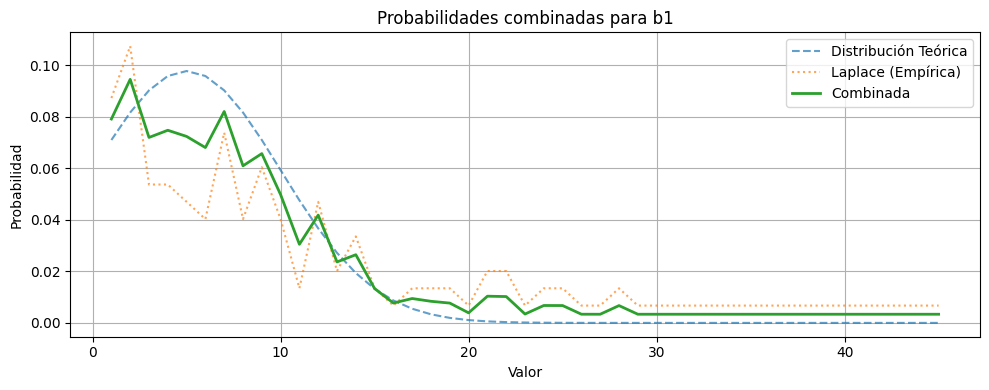

🎯 Siguientes valores más probables para b1:
  2: 0.0945
  7: 0.0820
  1: 0.0791
  4: 0.0747
  5: 0.0724
  3: 0.0720
  6: 0.0680
  9: 0.0657
  8: 0.0610
  10: 0.0498


In [288]:
b1_vals = next_gen_analyze("b1", body_size=104)

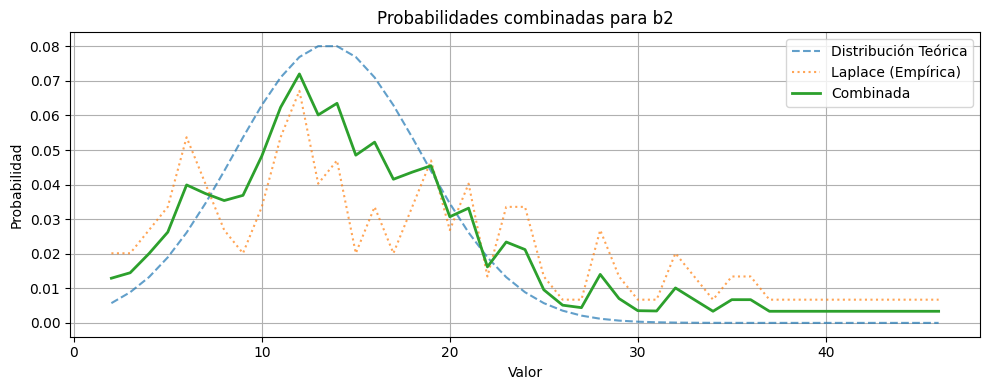

🎯 Siguientes valores más probables para b2:
  12: 0.0720
  14: 0.0635
  11: 0.0623
  13: 0.0602
  16: 0.0523
  15: 0.0485
  10: 0.0483
  19: 0.0455
  18: 0.0436
  17: 0.0415


In [289]:
b2_vals = next_gen_analyze("b2", body_size=104)

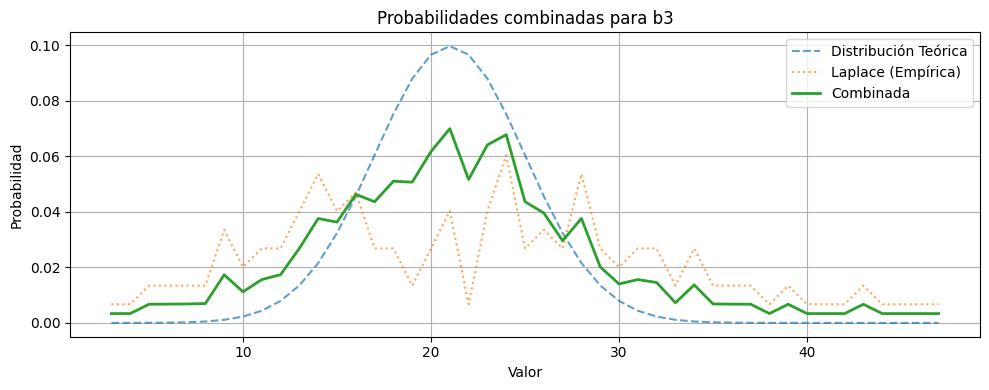

🎯 Siguientes valores más probables para b3:
  21: 0.0700
  24: 0.0678
  23: 0.0641
  20: 0.0618
  22: 0.0517
  18: 0.0511
  19: 0.0507
  16: 0.0463
  17: 0.0437
  25: 0.0437


In [290]:
b3_vals = next_gen_analyze("b3", body_size=104)

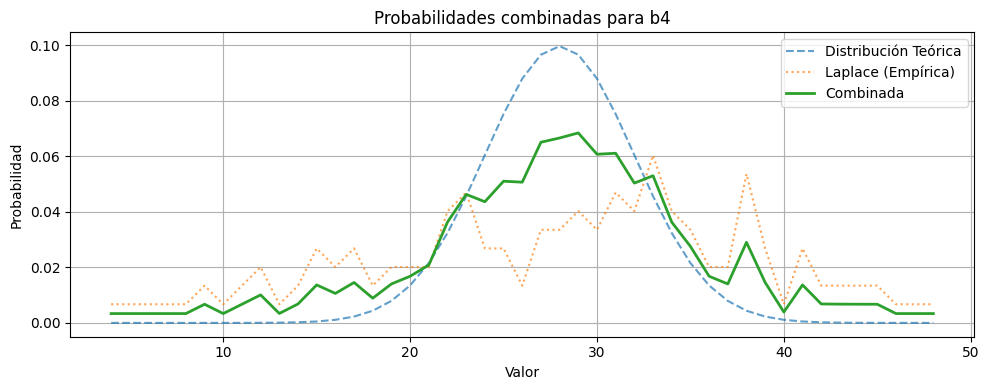

🎯 Siguientes valores más probables para b4:
  29: 0.0685
  28: 0.0666
  27: 0.0651
  31: 0.0611
  30: 0.0608
  33: 0.0530
  25: 0.0511
  26: 0.0507
  32: 0.0504
  23: 0.0463


In [291]:
b4_vals = next_gen_analyze("b4", body_size=104)

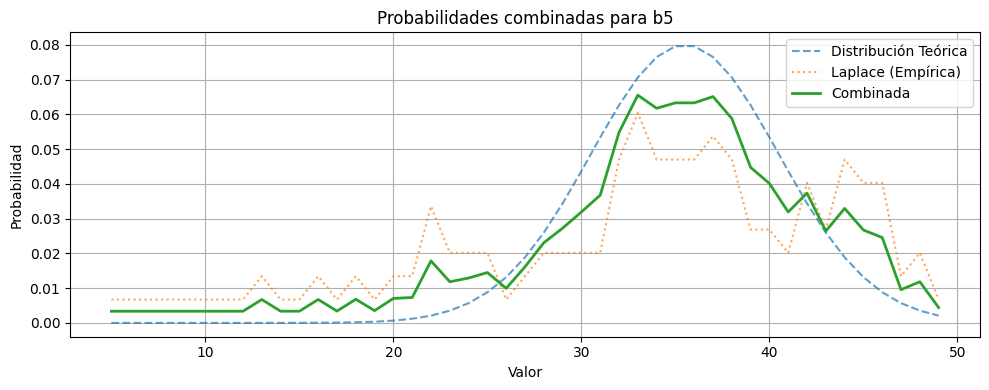

🎯 Siguientes valores más probables para b5:
  33: 0.0655
  37: 0.0651
  35: 0.0633
  36: 0.0633
  34: 0.0617
  38: 0.0588
  32: 0.0548
  39: 0.0447
  40: 0.0401
  42: 0.0373


In [292]:
b5_vals = next_gen_analyze("b5", body_size=104)

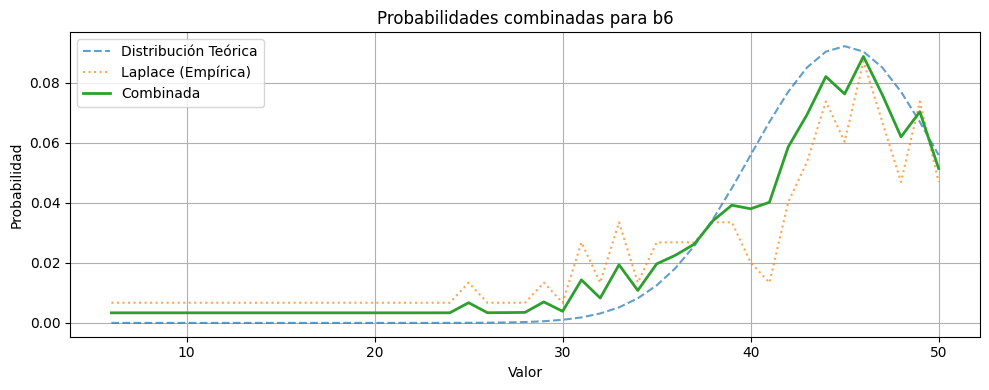

🎯 Siguientes valores más probables para b6:
  46: 0.0888
  44: 0.0821
  45: 0.0763
  47: 0.0761
  49: 0.0704
  43: 0.0694
  48: 0.0620
  42: 0.0587
  50: 0.0515
  41: 0.0402


In [293]:
b6_vals = next_gen_analyze("b6", body_size=104)